In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

from xgboost import XGBRegressor
import pickle

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("demand_forecasting.csv")

In [3]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [4]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [5]:
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [6]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [7]:
target = "Demand"

In [8]:
X = df[features].copy()

In [9]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [10]:
y = df[target]

In [11]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [12]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [13]:
lebal_encoder = {}

categorial_cols = X.select_dtypes(include = "object").columns

In [14]:
categorial_cols

Index(['Category'], dtype='object')

In [15]:
for col in categorial_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    lebal_encoder[col] = le

In [16]:
lebal_encoder

{'Category': LabelEncoder()}

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [18]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [19]:
xgb = XGBRegressor(objective = "reg:squarederror", n_jobs = -1)

In [20]:
param_dict = {
    "n_estimators" : [200, 300, 500],
    "max_depth" : [3, 4, 6, 8],
    "learning_rate" : [0.01, 0.05, 0.1],
    "subsample" : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5]
}

In [21]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [22]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [23]:
random_search.best_params_

{'subsample': 0.7,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [24]:
best_model = random_search.best_estimator_

In [25]:
y_pred = best_model.predict(X_test)

In [26]:
root_mean_squared_error(y_test, y_pred)

35.4190673828125

In [27]:
best_model.feature_importances_

array([0.11207438, 0.06178627, 0.03339339, 0.36474994, 0.04631266,
       0.38168335], dtype=float32)

In [28]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

In [29]:
feature_importance

Category              0.381683
Promotion             0.364750
Price                 0.112074
Discount              0.061786
Competitor Pricing    0.046313
Inventory Level       0.033393
dtype: float32

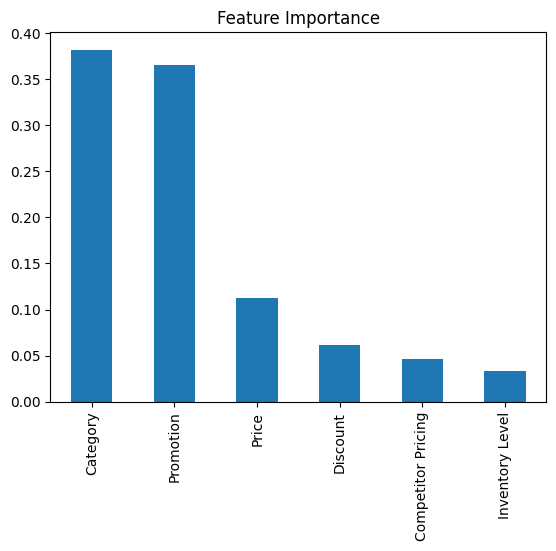

In [30]:
feature_importance.plot(kind = "bar", title = "Feature Importance")
plt.show()

In [31]:
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(lebal_encoder, f)

In [32]:
with open("xgboost_demand_model.pkl", "wb") as f:
    pickle.dump(best_model, f)